# TFT Model Evaluation Notebook

This notebook loads our trained Temporal Fusion Transformer model, makes predictions on test data, and visualizes the predicted vs actual price movements.

In [11]:
import os
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import psycopg2
from datetime import datetime, timedelta
from models.temporal_fusion_transformer import TemporalFusionTransformer, MarketDataset
from torch.utils.data import DataLoader

# Configure plots
plt.style.use('ggplot')
sns.set(font_scale=1.2)
plt.rcParams['figure.figsize'] = [12, 8]

## 1. Database Connection & Data Loading

In [12]:
# Database configuration
DB_CONFIG = {
    'host': 'localhost',
    'port': 5438,
    'user': 'backtest_user',
    'password': 'backtest_password',
    'database': 'backtest_db'
}

def get_db_connection():
    # Create a connection to the PostgreSQL database
    try:
        conn = psycopg2.connect(
            host=DB_CONFIG['host'],
            port=DB_CONFIG['port'],
            user=DB_CONFIG['user'],
            password=DB_CONFIG['password'],
            database=DB_CONFIG['database']
        )
        return conn
    except Exception as e:
        print(f"Error connecting to database: {type(e).__name__} - {str(e)}")
        return None

In [13]:
# Connect to database and load data
conn = get_db_connection()

# Query to get features
query = """
SELECT 
    timestamp,
    mid_price,
    spread,
    spread_pct,
    imbalance,
    new_bid_orders,
    new_ask_orders,
    canceled_bid_orders,
    canceled_ask_orders,
    next_price_1min,
    fill_probability
FROM tft_features
ORDER BY timestamp
"""

df = pd.read_sql_query(query, conn)
conn.close()

# Set timestamp as index
df.set_index('timestamp', inplace=True)

# Calculate target (price change)
df['target'] = df['next_price_1min'] / df['mid_price'] - 1

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df.index[0]} to {df.index[-1]}")

df.head()

Dataset shape: (10988, 11)
Date range: 2025-04-23 23:32:00+00:00 to 2025-05-01 14:39:00+00:00


/var/folders/nl/1k350bws5sdcymcpn81f46j40000gn/T/ipykernel_58181/1673984563.py:22: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn)


,mid_price,spread,spread_pct,imbalance,new_bid_orders,new_ask_orders,canceled_bid_orders,canceled_ask_orders,next_price_1min,fill_probability,target
timestamp,,,,,,,,,,,
2025-04-23 23:32:00+00:00,0.86605,0.0001,0.011547,-0.231516,0,0,0,0,0.86225,0.3842,-0.004388
2025-04-23 23:33:00+00:00,0.86315,0.0001,0.011585,-0.146391,0,0,0,0,0.85805,0.4268,-0.005909
2025-04-23 23:34:00+00:00,0.85965,0.0001,0.011633,-0.198192,0,0,0,0,0.85665,0.4009,-0.003490
2025-04-23 23:35:00+00:00,0.85775,0.0001,0.011658,-0.209683,0,0,0,0,0.85435,0.3952,-0.003964
2025-04-23 23:36:00+00:00,0.85505,0.0001,0.011695,-0.327486,0,0,0,0,0.85595,0.3363,0.001053


## 2. Data Preparation

In [14]:
# Define feature columns
feature_columns = [
    'spread',
    'spread_pct',
    'imbalance',
    'new_bid_orders',
    'new_ask_orders',
    'canceled_bid_orders',
    'canceled_ask_orders',
    'fill_probability'
]

# Normalize features (same as in training script)
df_scaled = df.copy()
for col in feature_columns:
    mean = df[col].mean()
    std = df[col].std()
    df_scaled[col] = (df[col] - mean) / (std if std > 0 else 1)

# Split into train, validation, and test sets (use same ratios as training script)
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

train_size = int(len(df_scaled) * train_ratio)
val_size = int(len(df_scaled) * val_ratio)

train_data = df_scaled.iloc[:train_size]
val_data = df_scaled.iloc[train_size:train_size + val_size]
test_data = df_scaled.iloc[train_size + val_size:]

print(f"Train set: {len(train_data)} samples")
print(f"Validation set: {len(val_data)} samples")
print(f"Test set: {len(test_data)} samples")

Train set: 7691 samples
Validation set: 1648 samples
Test set: 1649 samples


## 3. Load the Trained Model

In [15]:
# Find the latest checkpoint
checkpoint_dir = 'checkpoints'
checkpoint_files = [f for f in os.listdir(checkpoint_dir) if f.endswith('.ckpt')]
checkpoint_files.sort(key=lambda x: os.path.getmtime(os.path.join(checkpoint_dir, x)))

latest_checkpoint = os.path.join(checkpoint_dir, checkpoint_files[-1]) if checkpoint_files else None
print(f"Loading model from checkpoint: {latest_checkpoint}")

# Initialize and load model
if latest_checkpoint:
    # Use classmethod to load from checkpoint
    model = TemporalFusionTransformer.load_from_checkpoint(latest_checkpoint)
else:
    # Initialize model with parameters if no checkpoint
    model = TemporalFusionTransformer(
        time_varying_features=8,  # Number of features in dataset
        hidden_size=64,
        num_heads=4,
        dropout=0.1,
        learning_rate=1e-3,
        context_length=10,  # 10 minutes of history
        prediction_length=1  # Predicting 1 minute ahead
    )
    print("No checkpoint found. Using untrained model.")

# Set model to evaluation mode
model.eval()

Loading model from checkpoint: checkpoints/tft-epoch=09-val_loss=0.0000.ckpt


TemporalFusionTransformer(
  (feature_layer): Linear(in_features=10, out_features=64, bias=True)
  (temporal_processing): LSTM(64, 64, num_layers=2, batch_first=True, dropout=0.1)
  (self_attention): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
  )
  (final_layer): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)

## 4. Create Data Loaders

In [17]:
# Define collate function for batching
def collate_fn(batch):
    """Custom collate function to handle batching of temporal sequences."""
    # Stack all temporal features
    temporal_features = torch.stack([item['temporal_features'] for item in batch], dim=0)
    targets = torch.stack([item['targets'] for item in batch], dim=0)
    
    output = {
        'temporal_features': temporal_features,
        'targets': targets
    }
    
    # Handle static features if they exist
    if 'static_features' in batch[0]:
        static_features = torch.stack([item['static_features'] for item in batch], dim=0)
        output['static_features'] = static_features
    
    return output

# Create datasets
batch_size = 64
sequence_length = 10

# Create test dataset
test_dataset = MarketDataset(
    test_data, 
    context_length=sequence_length,
    prediction_length=1,
    target_column='target'
)

# Create test dataloader
test_loader = DataLoader(
    test_dataset, 
    batch_size=batch_size, 
    shuffle=False,
    collate_fn=collate_fn
)

print(f"Number of batches in test loader: {len(test_loader)}")

Number of batches in test loader: 26


## 5. Generate Predictions

In [18]:
# Collect test predictions
actual_values = []
predicted_values = []
timestamps = []

with torch.no_grad():
    for batch in test_loader:
        # Get input features and target values
        temporal_features = batch['temporal_features']
        targets = batch['targets'].squeeze(-1)
        
        # Make predictions
        predictions = model(None, temporal_features).squeeze(-1)
        
        # Collect results
        actual_values.extend(targets.cpu().numpy())
        predicted_values.extend(predictions.cpu().numpy())

# Convert lists to numpy arrays for proper calculations
actual_values = np.array(actual_values)
predicted_values = np.array(predicted_values)

# Ensure arrays are 1-dimensional
if len(actual_values.shape) > 1:
    actual_values = actual_values.flatten()
if len(predicted_values.shape) > 1:
    predicted_values = predicted_values.flatten()
    
print(f"Shape of actual values: {actual_values.shape}")
print(f"Shape of predicted values: {predicted_values.shape}")

# Create a DataFrame with predictions
test_indices = test_data.index[-len(actual_values):]
results_df = pd.DataFrame({
    'timestamp': test_indices,
    'actual_return': actual_values,
    'predicted_return': predicted_values
})
results_df.set_index('timestamp', inplace=True)

# Calculate evaluation metrics
mae = np.mean(np.abs(results_df['actual_return'] - results_df['predicted_return']))
mse = np.mean((results_df['actual_return'] - results_df['predicted_return'])**2)
rmse = np.sqrt(mse)

# Safely calculate correlation
if len(actual_values) > 0 and len(predicted_values) > 0:
    correlation = np.corrcoef(actual_values, predicted_values)[0, 1]
    print(f"Correlation: {correlation:.6f}")
else:
    print("Warning: No predictions generated, cannot calculate correlation")

print(f"Mean Absolute Error (MAE): {mae:.6f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.6f}")

# Show samples of results
results_df.head()

Shape of actual values: (1639,)
Shape of predicted values: (1639,)
Correlation: 0.011358
Mean Absolute Error (MAE): 0.020719
Root Mean Squared Error (RMSE): 0.034300


,actual_return,predicted_return
timestamp,,
2025-04-30 11:21:00+00:00,0.0,0.000347
2025-04-30 11:22:00+00:00,0.0,0.000347
2025-04-30 11:23:00+00:00,0.0,0.000347
2025-04-30 11:24:00+00:00,0.0,0.000347
2025-04-30 11:25:00+00:00,0.0,0.000347


## 6. Visualize Predictions

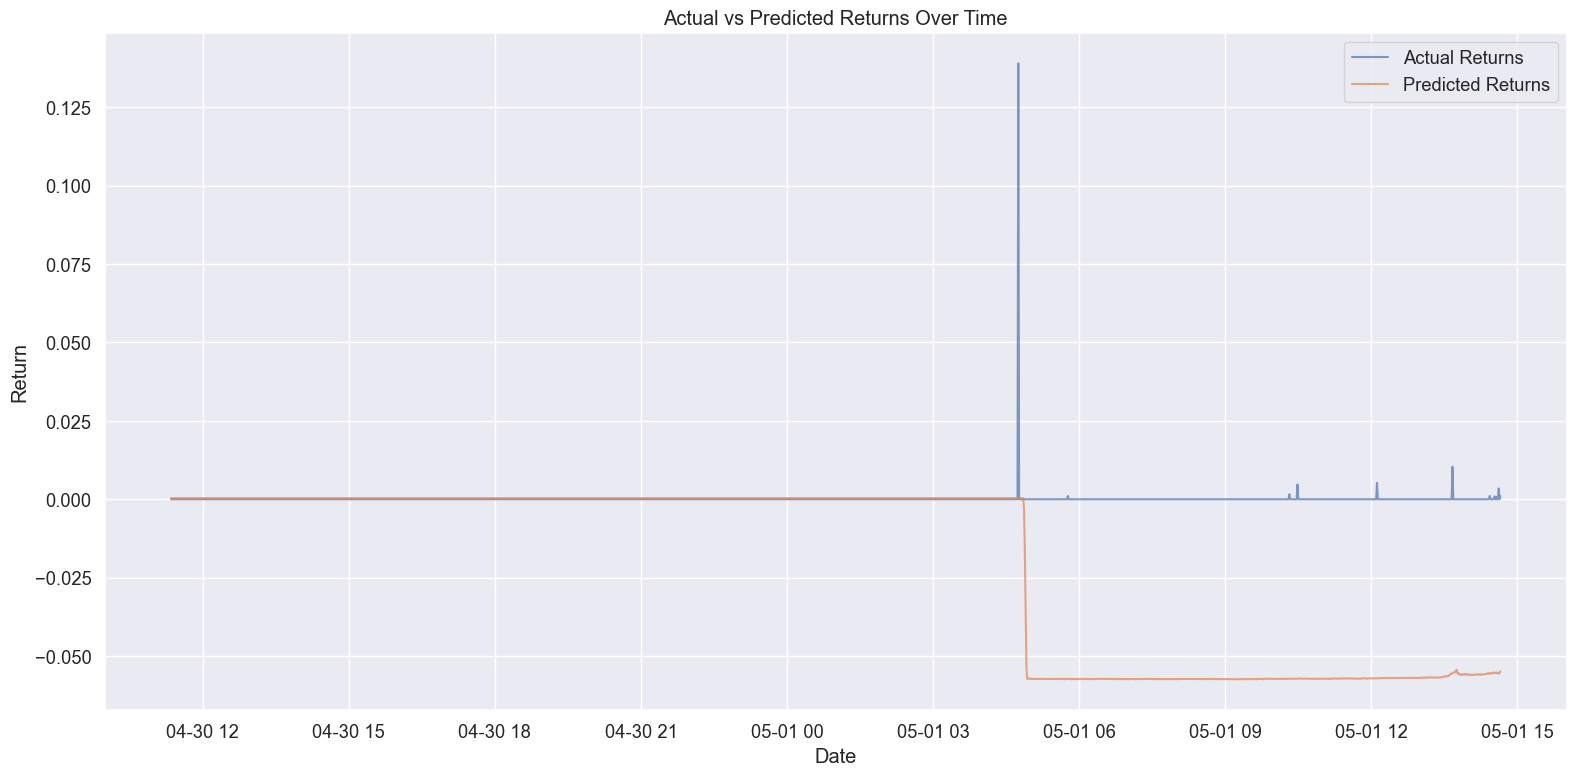

In [19]:
# Time series of predictions versus actual values
plt.figure(figsize=(16, 8))
plt.plot(results_df.index, results_df['actual_return'], label='Actual Returns', alpha=0.7)
plt.plot(results_df.index, results_df['predicted_return'], label='Predicted Returns', alpha=0.7)
plt.title('Actual vs Predicted Returns Over Time')
plt.xlabel('Date')
plt.ylabel('Return')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

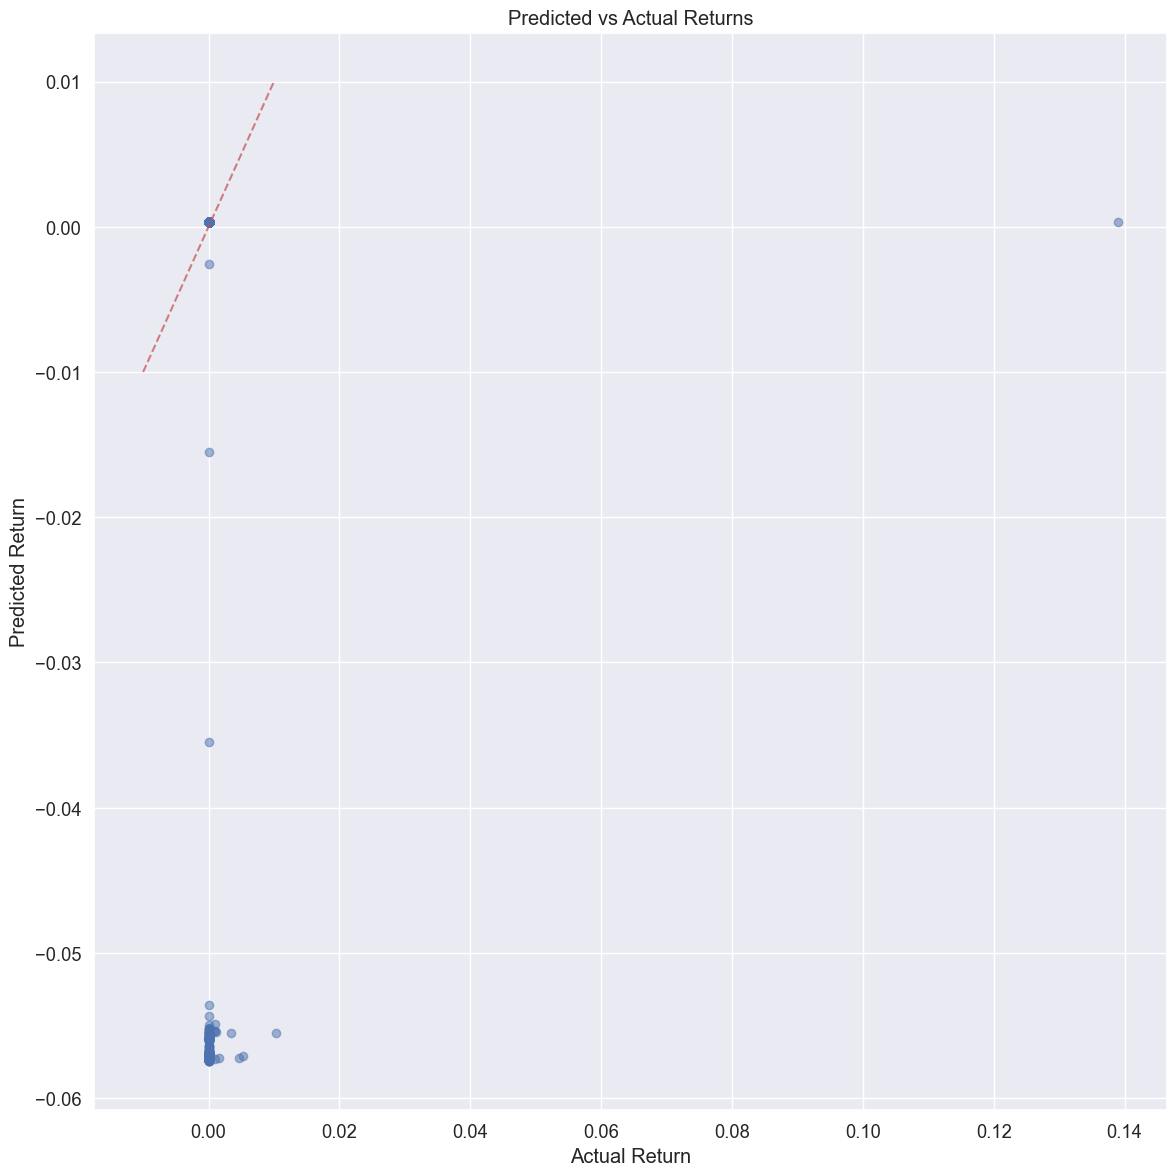

In [20]:
# Scatter plot of predicted vs actual
plt.figure(figsize=(12, 12))
plt.scatter(results_df['actual_return'], results_df['predicted_return'], alpha=0.5)
plt.plot([-0.01, 0.01], [-0.01, 0.01], 'r--', alpha=0.7)
plt.title('Predicted vs Actual Returns')
plt.xlabel('Actual Return')
plt.ylabel('Predicted Return')
plt.grid(True)
plt.tight_layout()
plt.show()